In [1]:
import slmcontrol
import numpy as np
import matplotlib.pyplot as plt
from common.utils import generate_amplitude_and_phase_hologram, fourier_transform, resize_and_center
import h5py
import matplotlib.pyplot as plt

In [3]:
slm = slmcontrol.SLMDisplay(host="localhost")

In [4]:
N = 256
_xs = np.arange(N) - N // 2
_ys = np.arange(N) - N // 2
xs, ys = np.meshgrid(_xs, _ys)

In [18]:
mode = slmcontrol.hg(xs, ys, w=50, m=5, n=5)
holo = generate_amplitude_and_phase_hologram(mode, - np.angle(mode), 192, 4, np.inf, slm_shape=(slm.height, slm.width // 2))
slm.updateArray(holo)

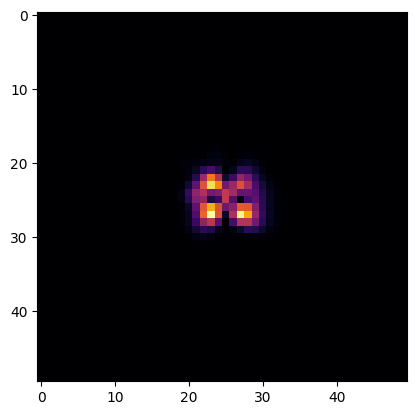

In [30]:
with h5py.File("results/new_setup/phases.h5") as f:
    phase = f["phases"][0, 2]
u = slmcontrol.hg(xs, ys, w=30, m=1, n=1) - 0.5j * slmcontrol.hg(xs, ys, w=30, m=0, n=2)
ft_u = fourier_transform(u * np.exp(1j * phase))
plt.imshow(np.abs(ft_u[N//2-25:N//2+25, N//2-25:N//2+25])**2, cmap="inferno")

holo = generate_amplitude_and_phase_hologram(u, phase, 192, 4, np.inf, slm_shape=(slm.height, slm.width // 2))
slm.updateArray(holo)